<a href="https://colab.research.google.com/github/vsmalladi/FAIRBio/blob/main/fairbio/notebooks/ga4gh_trs_workflows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explore Workflows from TRS Endpoints

In [1]:
!pip install git+https://github.com/vsmalladi/FAIRBio

  Cloning https://github.com/vsmalladi/FAIRBio to /tmp/pip-req-build-orrc89oj
  Running command git clone --filter=blob:none --quiet https://github.com/vsmalladi/FAIRBio /tmp/pip-req-build-orrc89oj
  Resolved https://github.com/vsmalladi/FAIRBio to commit 926e84f4bcd4bccc9fd0a3d2f69c1ca58dc59496
  Preparing metadata (setup.py) ... done
  Created wheel for fairbio: filename=fairbio-0.1.0-py3-none-any.whl size=18426 sha256=e8c17cfd612415a0de7f582a98f5af87d42c4f53d303b81ce27808d80dad0fa0
  Stored in directory: /tmp/pip-ephem-wheel-cache-9lwu2dcl/wheels/f3/84/13/94ff52c8516b324e2df2c98669fde34a6fcab49ec51757c29a
Successfully built fairbio


## Download workflows from Dockstore


In [2]:
!fairbio-trs -v -r https://dockstore.org/api tools --all --toolclass Workflow -o dockstore_workflows.json

🔍 Fetching ALL tools from https://dockstore.org/api...
   (This may take a while, automatically paginating through all results...)
Starting new HTTPS connection (1): dockstore.org:443
https://dockstore.org:443 "GET /api/ga4gh/trs/v2/tools?limit=100&offset=0&toolClass=Workflow HTTP/1.1" 200 None
https://dockstore.org:443 "GET /api/ga4gh/trs/v2/tools?toolClass=Workflow&limit=100&offset=1 HTTP/1.1" 200 None
https://dockstore.org:443 "GET /api/ga4gh/trs/v2/tools?toolClass=Workflow&limit=100&offset=2 HTTP/1.1" 200 None
https://dockstore.org:443 "GET /api/ga4gh/trs/v2/tools?toolClass=Workflow&limit=100&offset=3 HTTP/1.1" 200 None
https://dockstore.org:443 "GET /api/ga4gh/trs/v2/tools?toolClass=Workflow&limit=100&offset=4 HTTP/1.1" 200 None
https://dockstore.org:443 "GET /api/ga4gh/trs/v2/tools?toolClass=Workflow&limit=100&offset=5 HTTP/1.1" 200 None
https://dockstore.org:443 "GET /api/ga4gh/trs/v2/tools?toolClass=Workflow&limit=100&offset=6 HTTP/1.1" 200 None
https://dockstore.org:443 "GET /

## Download workflows from Workflowhub

In [22]:
!fairbio-trs -v -r https://workflowhub.eu/ tools --all -o workflowhub.json

🔍 Fetching ALL tools from https://workflowhub.eu/...
   (This may take a while, automatically paginating through all results...)
Starting new HTTPS connection (1): workflowhub.eu:443
https://workflowhub.eu:443 "GET /ga4gh/trs/v2/tools?limit=100&offset=0 HTTP/1.1" 200 None
https://workflowhub.eu:443 "GET /ga4gh/trs/v2/tools?limit=100&offset=100 HTTP/1.1" 200 None
https://workflowhub.eu:443 "GET /ga4gh/trs/v2/tools?limit=100&offset=200 HTTP/1.1" 200 None
https://workflowhub.eu:443 "GET /ga4gh/trs/v2/tools?limit=100&offset=300 HTTP/1.1" 200 None
https://workflowhub.eu:443 "GET /ga4gh/trs/v2/tools?limit=100&offset=400 HTTP/1.1" 200 None
https://workflowhub.eu:443 "GET /ga4gh/trs/v2/tools?limit=100&offset=500 HTTP/1.1" 200 None
https://workflowhub.eu:443 "GET /ga4gh/trs/v2/tools?limit=100&offset=600 HTTP/1.1" 200 None
https://workflowhub.eu:443 "GET /ga4gh/trs/v2/tools?limit=100&offset=700 HTTP/1.1" 200 None
https://workflowhub.eu:443 "GET /ga4gh/trs/v2/tools?limit=100&offset=800 HTTP/1.1" 

## Unique Workflows


In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
def load_workflow_registry(filepath: str) -> pd.DataFrame:
    """Load a TRS workflow JSON file and return a normalized DataFrame."""
    with open(filepath) as f:
        data = json.load(f)

    tools = data['tools'] if isinstance(data, dict) else data
    df = pd.json_normalize(tools)

    if 'versions' in df.columns:
        df['descriptor_types'] = df['versions'].apply(
            lambda versions: sorted(set(
                dtype
                for v in (versions or [])
                for dtype in (v.get('descriptor_type') or [])
            ))
        )

    return df

In [24]:
dockstore_processed = load_workflow_registry('dockstore_workflows.json')
workflowhub_processed = load_workflow_registry('workflowhub.json')

In [43]:
def plot_descriptor_type_counts(df: pd.DataFrame, title: str = "Workflows by Descriptor Type") -> None:
    """Bar chart of workflow counts by descriptor type."""
    counts = (
        df['descriptor_types']
        .explode()
        .dropna()
        .loc[lambda x: (x != '') & (x != '[]')]
        .value_counts()
        .sort_values(ascending=False)
    )

    if counts.empty:
        print(f"No descriptor type data found for: {title}")
        return

    colors = list(plt.cm.tab10.colors[:len(counts)])

    fig, ax = plt.subplots(figsize=(8, 5))
    counts.plot.bar(ax=ax, color=colors, edgecolor='white')

    for bar, value in zip(ax.patches, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + counts.max() * 0.01,
            str(value),
            ha='center', va='bottom', fontweight='bold', fontsize=10
        )

    ax.set_title(title)
    ax.set_xlabel("Descriptor Type")
    ax.set_ylabel("Number of Workflows")
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, counts.max() * 1.12)
    plt.tight_layout()
    plt.show()

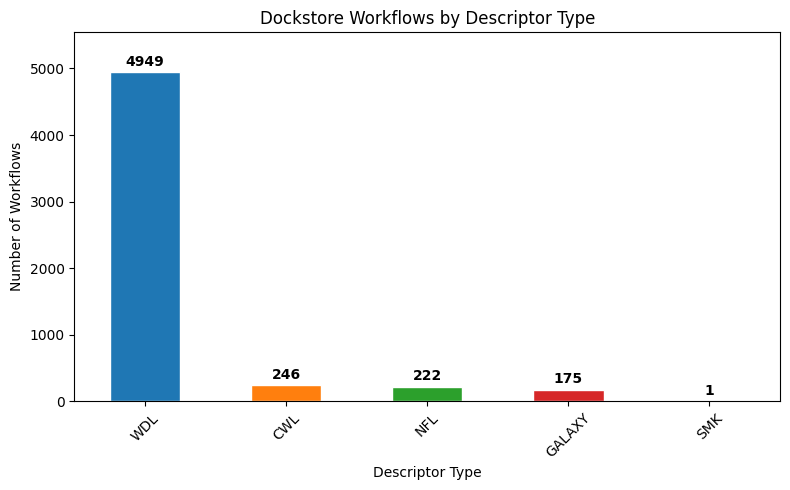

In [44]:
plot_descriptor_type_counts(dockstore_processed, title="Dockstore Workflows by Descriptor Type")


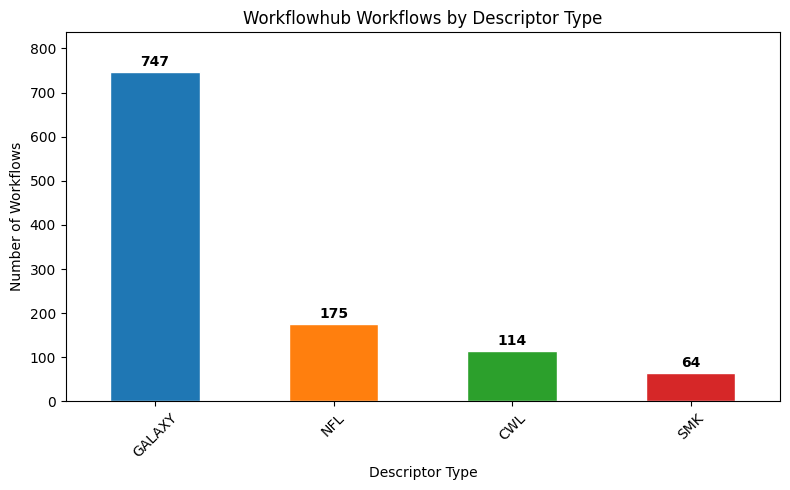

In [46]:
plot_descriptor_type_counts(workflowhub_processed, title="Workflowhub Workflows by Descriptor Type")
